In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder


Generating Panel A: Prehension PCA...
Generating Panel B: Aiming PCA...
Generating Panel C: Illusion Susceptibility Scores...


c:\CourseWork\Classifying_grip_strategies_ml\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:14:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\bharg\AppData\Local\Temp\ipykernel_3888\4143955760.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], x='subjName', y='susceptibility_score', data=subject_scores,


Generating Panel D: Kinematic Response Distributions...

'Grand Summary' visualization saved to results/figures/grand_summary_visualization.png


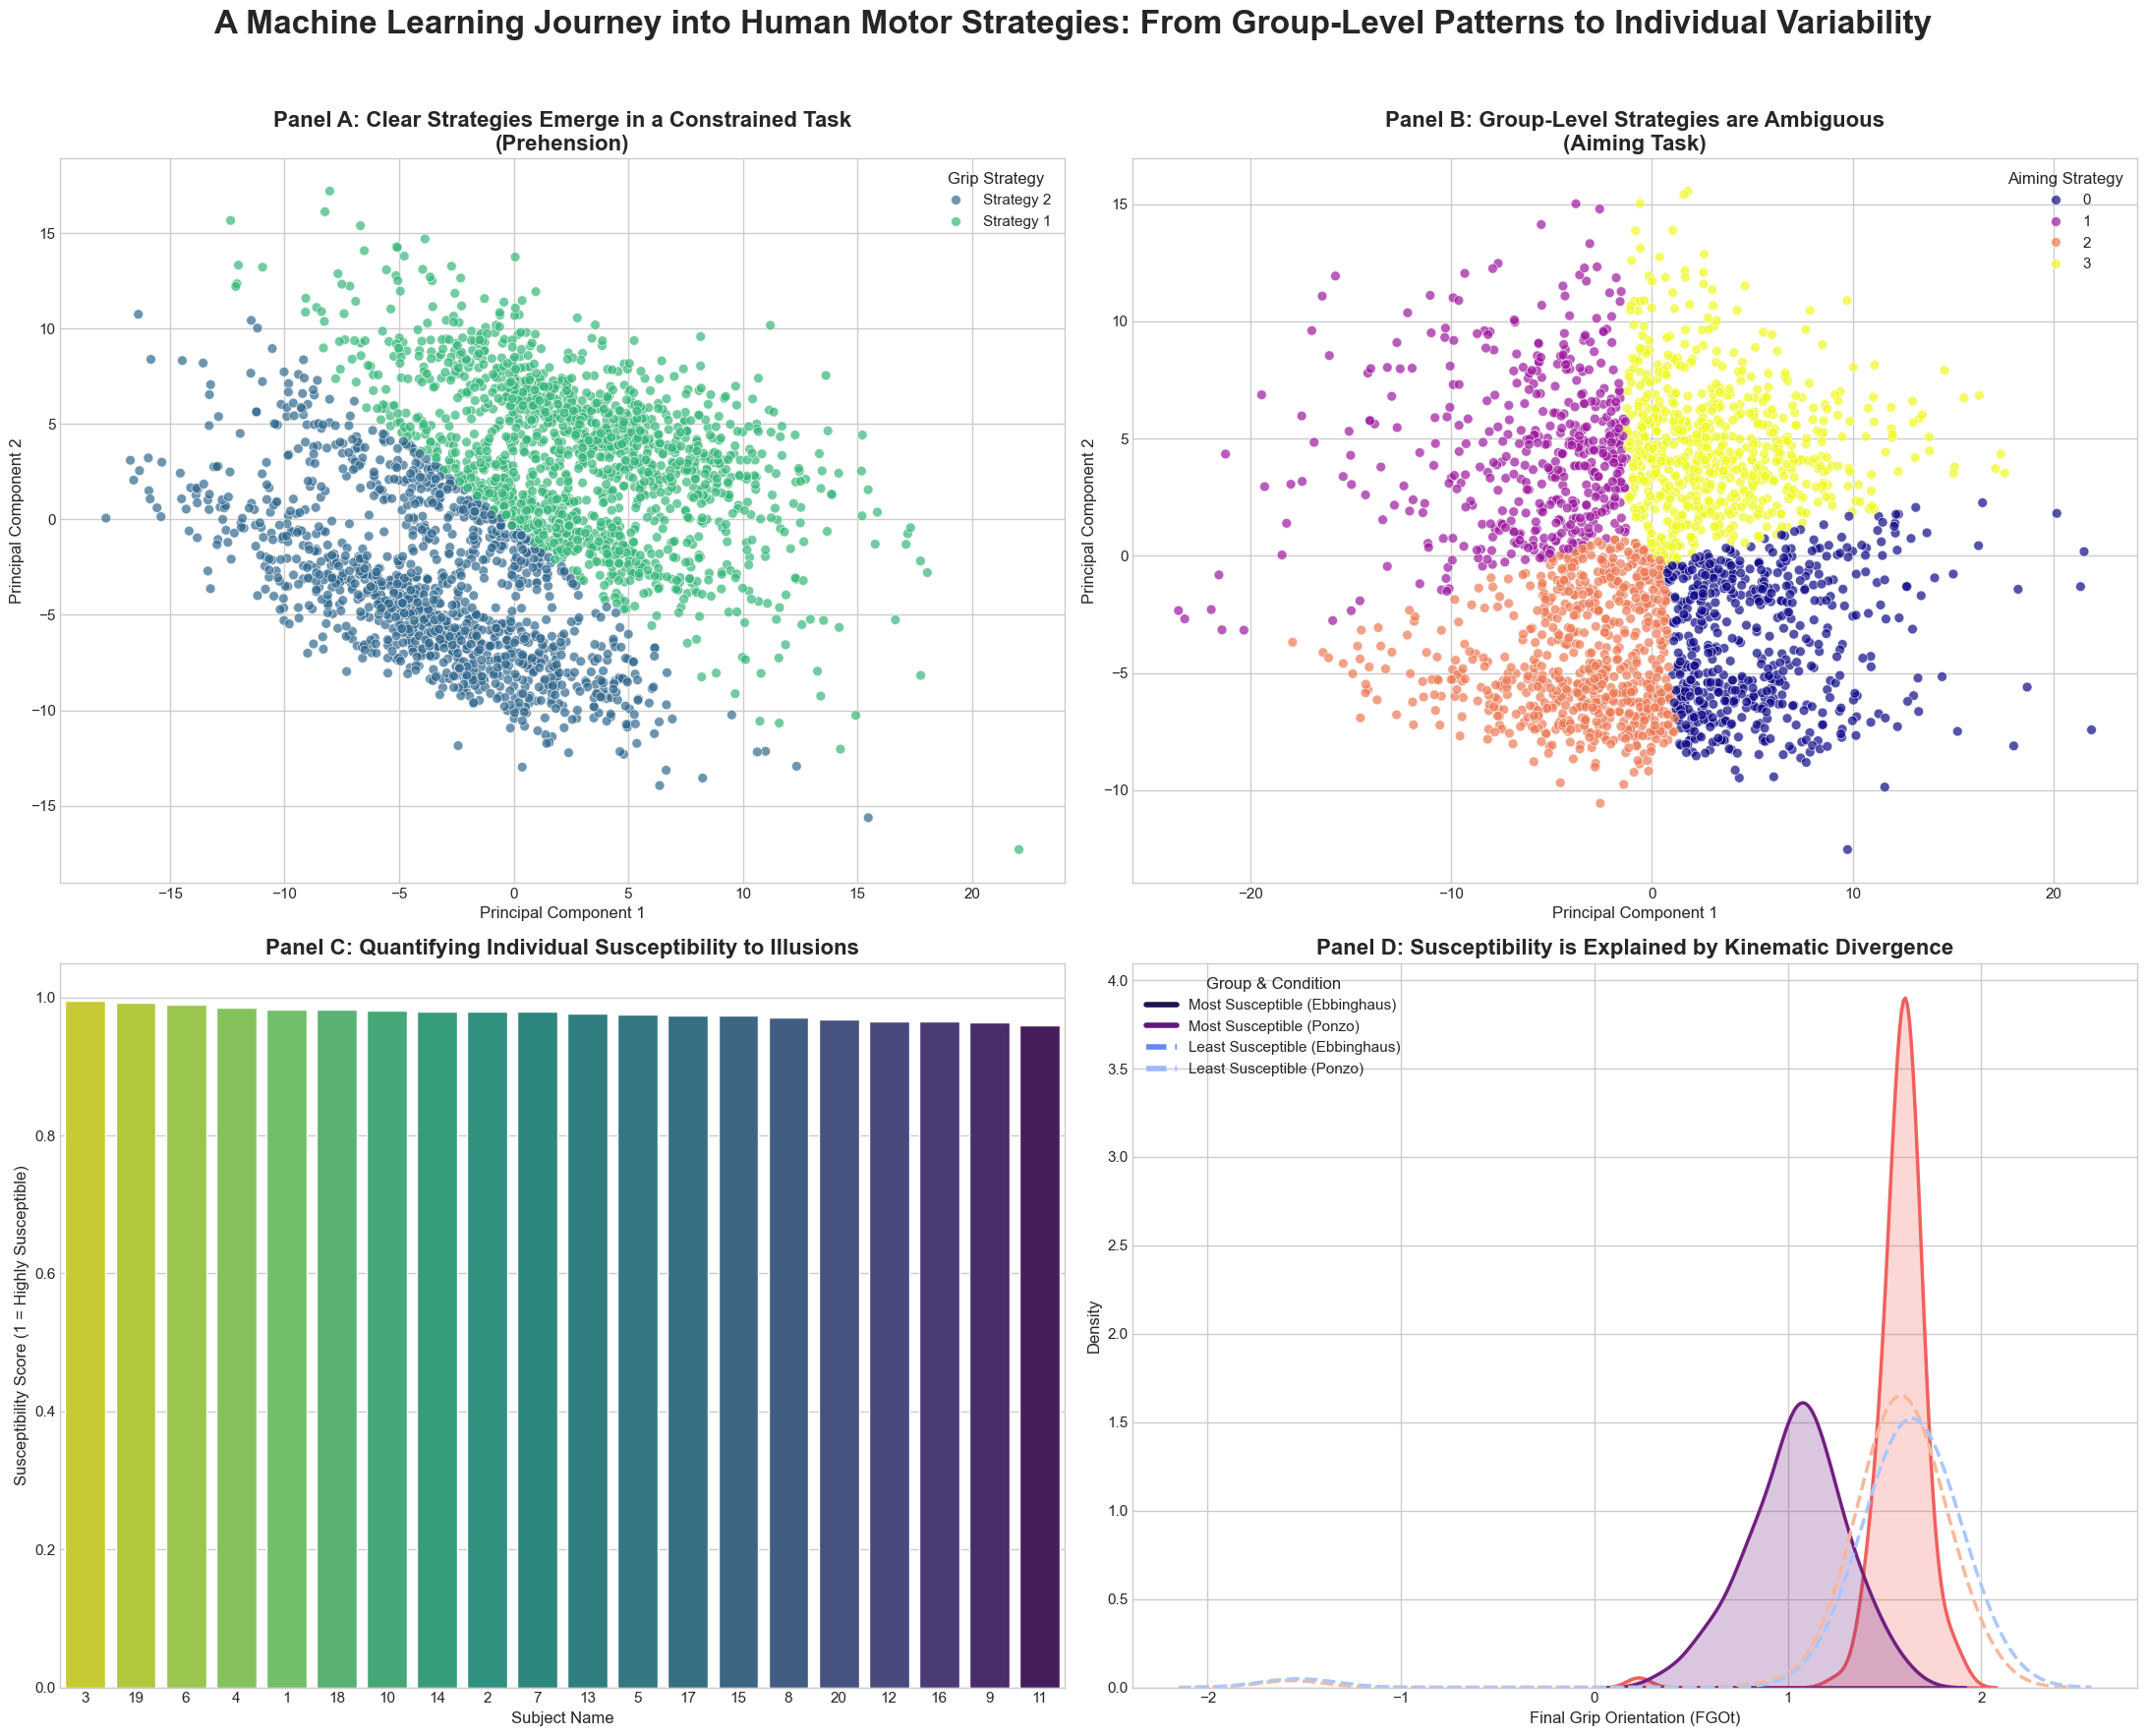

In [ ]:
# Setup and Styling
# Set a consistent style for the plots
sns.set_theme(style="whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')

# Create the 2x2 figure layout
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.suptitle('A Machine Learning Journey into Human Motor Strategies: From Group-Level Patterns to Individual Variability', fontsize=24, weight='bold')

# Panel A: Clear Strategies in a Constrained Task (Prehension)
print("Generating Panel A: Prehension PCA...")
df_prehension = pd.read_csv("../../data/02_processed/prehension_master_dataset.csv")

# Prepare data for clustering
kinematic_features_pre = df_prehension.select_dtypes(include=np.number).drop(columns=['subjName', 'trialN']).columns
X_pre = df_prehension[kinematic_features_pre]
X_pre_scaled = StandardScaler().fit_transform(X_pre)
X_pre_pca = PCA(n_components=2).fit_transform(X_pre_scaled)

# Perform clustering for k=2
kmeans_pre = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_prehension['strategy'] = kmeans_pre.fit_predict(X_pre_pca)

# Create a dataframe for plotting
pca_pre_df = pd.DataFrame(data=X_pre_pca, columns=['PC1', 'PC2'])
pca_pre_df['strategy'] = df_prehension['strategy']
pca_pre_df['strategy'] = pca_pre_df['strategy'].map({0: 'Strategy 1', 1: 'Strategy 2'}) # Rename for clarity

# Plot on the first subplot
sns.scatterplot(ax=axes[0, 0], data=pca_pre_df, x='PC1', y='PC2', hue='strategy', palette='viridis', s=50, alpha=0.7)
axes[0, 0].set_title('Panel A: Clear Strategies Emerge in a Constrained Task\n(Prehension)', fontsize=16, weight='bold')
axes[0, 0].set_xlabel('Principal Component 1', fontsize=12)
axes[0, 0].set_ylabel('Principal Component 2', fontsize=12)
axes[0, 0].legend(title='Grip Strategy')



# Panel B: Ambiguous Strategies in a Less-Constrained Task (Aiming)

print("Generating Panel B: Aiming PCA...")
df_aiming = pd.read_csv("../../data/02_processed/aiming_master_dataset.csv")

# Prepare data
kinematic_features_aim = df_aiming.select_dtypes(include=np.number).drop(columns=['subjName', 'trialN']).columns
X_aim = df_aiming[kinematic_features_aim]
X_aim_scaled = StandardScaler().fit_transform(X_aim)
X_aim_pca = PCA(n_components=2).fit_transform(X_aim_scaled)

# Perform clustering for k=4 to show the "messy" nature
kmeans_aim = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_aiming['strategy'] = kmeans_aim.fit_predict(X_aim_pca)

# Create a dataframe for plotting
pca_aim_df = pd.DataFrame(data=X_aim_pca, columns=['PC1', 'PC2'])
pca_aim_df['strategy'] = df_aiming['strategy']

# Plot on the second subplot
sns.scatterplot(ax=axes[0, 1], data=pca_aim_df, x='PC1', y='PC2', hue='strategy', palette='plasma', s=50, alpha=0.7)
axes[0, 1].set_title('Panel B: Group-Level Strategies are Ambiguous\n(Aiming Task)', fontsize=16, weight='bold')
axes[0, 1].set_xlabel('Principal Component 1', fontsize=12)
axes[0, 1].set_ylabel('Principal Component 2', fontsize=12)
axes[0, 1].legend(title='Aiming Strategy')


# Panel C: Quantifying Individual "Kinematic Susceptibility"
print("Generating Panel C: Illusion Susceptibility Scores...")
df_illusions = pd.read_csv("../../data/02_processed/visual_illusions_master_dataset.csv")

# Use the susceptibility score calculation from Phase 4
def get_curated_features(df, drop_cols=[]):
    leaky_patterns = ['Xmax', 'Ymax', 'Zmax', 'FX', 'FY', 'FZ', 'Xloc', 'Yloc', 'Zloc']
    identifiers = ['subjName', 'trialN']
    kinematic_features = df.select_dtypes(include=np.number).columns.tolist()
    kinematic_features = [col for col in kinematic_features if col not in identifiers and col not in drop_cols]
    return [feat for feat in kinematic_features if not any(pattern in feat for pattern in leaky_patterns)]

features_illusions = get_curated_features(df_illusions, drop_cols=['targetSize'])
X_ill = df_illusions[features_illusions]
y_ill = df_illusions['illusion']
le = LabelEncoder()
y_ill_encoded = le.fit_transform(y_ill)
ponzo_class_index = list(le.classes_).index('Ponzo')

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])
pipeline_xgb.fit(X_ill, y_ill_encoded)
probabilities = pipeline_xgb.predict_proba(X_ill)
df_illusions['P(Ponzo)'] = probabilities[:, ponzo_class_index]
df_illusions['ambiguity_score'] = 1 - np.abs(df_illusions['P(Ponzo)'] - 0.5) * 2
subject_scores = df_illusions.groupby('subjName')['ambiguity_score'].mean().reset_index()
subject_scores['susceptibility_score'] = 1 - subject_scores['ambiguity_score']
subject_scores = subject_scores.sort_values('susceptibility_score', ascending=False)

# Plot on the third subplot
sns.barplot(ax=axes[1, 0], x='subjName', y='susceptibility_score', data=subject_scores,
            order=subject_scores['subjName'], palette='viridis_r') # Use reversed palette for contrast
axes[1, 0].set_title('Panel C: Quantifying Individual Susceptibility to Illusions', fontsize=16, weight='bold')
axes[1, 0].set_xlabel('Subject Name', fontsize=12)
axes[1, 0].set_ylabel('Susceptibility Score (1 = Highly Susceptible)', fontsize=12)
axes[1, 0].set_ylim(0, 1.05)


# Panel D: Kinematics Reveal the Source of Susceptibility
print("Generating Panel D: Kinematic Response Distributions...")
# Get the most and least susceptible subjects
n_subjects_to_compare = 3
least_susceptible_subjects = subject_scores.tail(n_subjects_to_compare)['subjName'].tolist()
most_susceptible_subjects = subject_scores.head(n_subjects_to_compare)['subjName'].tolist()

df_least = df_illusions[df_illusions['subjName'].isin(least_susceptible_subjects)]
df_most = df_illusions[df_illusions['subjName'].isin(most_susceptible_subjects)]

# Plot distributions for both groups on the fourth subplot
sns.kdeplot(ax=axes[1, 1], data=df_most, x='FGOt', hue='illusion', fill=True, 
            common_norm=False, palette='magma', linewidth=2.5, label='_nolegend_')

# Overlay the distributions for the least susceptible group with dashed lines for contrast
sns.kdeplot(
    ax=axes[1, 1], 
    data=df_least, 
    x='FGOt', 
    hue='illusion', 
    common_norm=False, 
    palette='coolwarm', 
    linestyle='--',  # <-- Fix
    linewidth=2.5, 
    fill=False, 
    legend=False
)

axes[1, 1].set_title('Panel D: Susceptibility is Explained by Kinematic Divergence', fontsize=16, weight='bold')
axes[1, 1].set_xlabel('Final Grip Orientation (FGOt)', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)

# Create a custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=sns.color_palette('magma')[0], lw=4, label='Most Susceptible (Ebbinghaus)'),
    Line2D([0], [0], color=sns.color_palette('magma')[1], lw=4, label='Most Susceptible (Ponzo)'),
    Line2D([0], [0], color=sns.color_palette('coolwarm')[0], lw=4, linestyle='--', label='Least Susceptible (Ebbinghaus)'),
    Line2D([0], [0], color=sns.color_palette('coolwarm')[1], lw=4, linestyle='--', label='Least Susceptible (Ponzo)')
]
axes[1, 1].legend(handles=legend_elements, title='Group & Condition', loc='upper left')


# Final Touches
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.savefig("../../results/figures/grand_summary_visualization.png", dpi=300)
print("\n'Grand Summary' visualization saved to results/figures/grand_summary_visualization.png")
plt.show()
